In [ ]:
# Adapted from Anthropic Claude API Course
# Modified and extended for learning and experimentation

### Environmental Set up

In [2]:
# Install dependencies
%pip install anthropic python-dotenv

You should consider upgrading via the '/Users/upasanaghosh/ml-dev-workspace/building_with_claude_api/.buildingWithClaudeAPI/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [1]:
# Load env variables
from dotenv import load_dotenv
import os

print("API key loaded:", load_dotenv())

API key loaded: True


In [3]:
# Create API client
from anthropic import Anthropic

client = Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
model = "claude-sonnet-4-0"

### Helper Functions

In [4]:
def add_user_message(messages, text):
    user_message = {"role": "user", "content": text}
    messages.append(user_message)

def add_assistant_message(messages, text):
    assistant_message = {"role": "assistant", "content": text}
    messages.append(assistant_message)

# Controlling Outputs using Structured Data

When you need Claude to generate structured data like JSON, Python code, or bulleted lists, you'll often run into a common problem: Claude wants to be helpful and add explanatory text around your content. To avoid this problem, we can combine <b>assistant message prefilling</b> with <b>stop sequences</b> to get exactly the content we want.

For ex, if we want Claude to generate just a JSON message, and use this technique, what happens internally is:
1. The user message tells Claude what to generate
2. The prefilled assistant message makes Claude think it already started a markdown code block
3. Claude continues by writing just the JSON content
4. When Claude tries to close the code block with ```, the stop sequence immediately ends generation

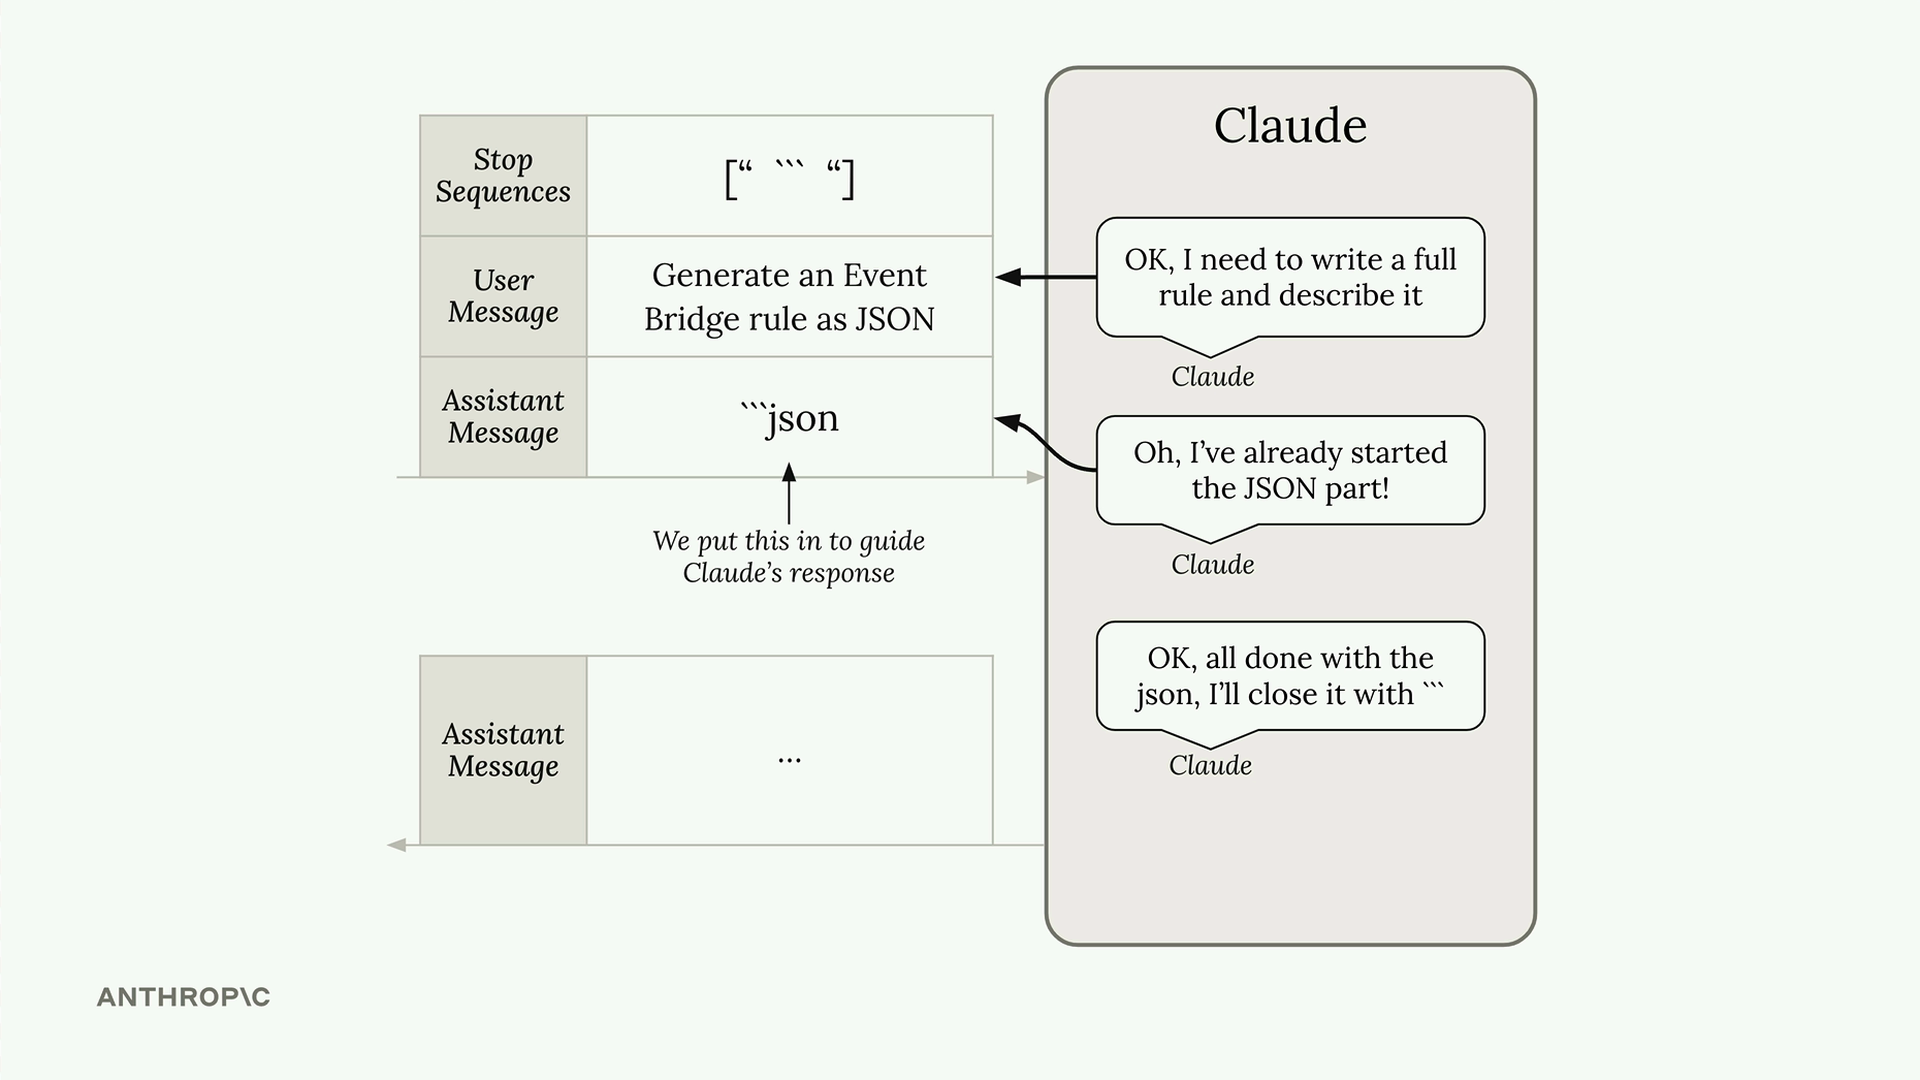

Let's see this in action with code...

In [11]:
def chat(messages, system=None, stop_sequences=None):
    params = {
        "model": model,
        "max_tokens": 1000,
        "messages": messages,
        "stop_sequences": stop_sequences
    }
    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message.content[0].text

In [12]:
messages = []

add_user_message(messages, "Generate a very short event bridge rule as json")
add_assistant_message(messages, "```json")

text = chat(messages, stop_sequences=["```"])

In [13]:
import json

# Clean up and parse the JSON
clean_json = json.loads(text.strip())

print("Parsed JSON output:", clean_json)

Parsed JSON output: {'Name': 'OrderProcessingRule', 'EventPattern': {'source': ['myapp.orders'], 'detail-type': ['Order Placed']}, 'Targets': [{'Id': '1', 'Arn': 'arn:aws:lambda:us-east-1:123456789012:function:ProcessOrder'}]}


## Exercise
- Use message prefilling and stop sequence only to get three different commands in a single response.
- There shouldn't be any comments or explainations
- Hint: Message prefilling isn't limited to just characters like ```

In [ ]:
messages = []

prompt = """
Generate three different sample AWS CLI commands. Each should be very short.
"""

add_user_message(messages, prompt)

 # No content, just to indicate assistant's turn
text = chat(messages)

text.strip()

'Here are three short AWS CLI commands:\n\n1. **List S3 buckets:**\n   ```bash\n   aws s3 ls\n   ```\n\n2. **Describe EC2 instances:**\n   ```bash\n   aws ec2 describe-instances\n   ```\n\n3. **Get current AWS user identity:**\n   ```bash\n   aws sts get-caller-identity\n   ```'

### Solution

In [21]:
messages = []

prompt = """
Generate three different sample AWS CLI commands. Each should be very short.
"""

add_user_message(messages, prompt)
add_assistant_message(messages, "Here are three different sample AWS CLI commands in a single block without any comments: \n```bash")

 # No content, just to indicate assistant's turn
text = chat(messages, stop_sequences=["```"])

text.strip()

'aws s3 ls s3://my-bucket\naws ec2 describe-instances --instance-ids i-1234567890abcdef0\naws iam list-users'

In [22]:
from IPython.display import Markdown

Markdown(text.strip())

aws s3 ls s3://my-bucket
aws ec2 describe-instances --instance-ids i-1234567890abcdef0
aws iam list-users